In [1]:
%load_ext autoreload
%autoreload 2

from IPython.display import Math, Latex

import pandas as pd, cvxpy as cp, numpy as np, matplotlib as mpl  # type: ignore
import matplotlib.pyplot as plt  # type: ignore

from matplotlib.ticker import FuncFormatter, MultipleLocator  # type: ignore
from matplotlib.patches import FancyArrowPatch, Polygon  # type: ignore
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

from scipy.integrate import quad  # type: ignore
from scipy.spatial import ConvexHull
from scipy.interpolate import interp1d

import importlib, itertools, csv, concurrent.futures
import os, math, sys, json, pickle, shutil, time, functools

from typing import Dict, List, Any, Optional, Literal
from tqdm.notebook import tqdm
import networkx as nx

from Utils import Notebook, tex, gph, sgn, nm, ds
from Simulator import *
# from SimulatorOld import *
from optimization import DisturbedSaturatedPETC as DSPETC
import TrafficModels as tm

cfg = {
    'style': {'color': 'black'},
    'axis': {
        'title_pad': 10,
        'x_label_fontsize': 16,
        'y_label_fontsize': 16,
        'tick_fontsize': 16,
    },
    'legend': {'fontsize': 16}
}

colors_list = plt.get_cmap('tab20').colors
Notebook.setup()

LaTeX has been enabled for text rendering.


### Definição da Planta

In [2]:
experiment_filename = 'exp-03'

with open(f"experiment-datas/{experiment_filename}.json", encoding='utf-8') as f:
  exp_data = json.load(f)

plant = ds.StateSpace(data=exp_data["plant"], name='plant')
latex_expr = plant.get_latex_equations()
print("Equações que regem a dinâmica da planta:")
tex.display_latex(latex_expr)

Equações que regem a dinâmica da planta:


<IPython.core.display.Latex object>

### Projeto do Controlador e do ETM

In [3]:
import Simulator
import matplotlib.pyplot as plt

# Parâmetros
EXPERIMENT_FILE = f"experiment-datas/{experiment_filename}.json"

In [4]:
def solve_problem(
    h: float,
    υ: float,
    α: float,
    eps: float = 1e-6,
):
  n_x = plant.nx
  n_u = plant.nu

  Onx = np.zeros((n_x, n_x))

  matrices = plant.evaluate_matrices(None, None, None)
  A = matrices['A']
  B = matrices['B']

  e = nm.get_e(5 * [n_x])

  for i in range(1, len(e)):
    e[i] = cp.Parameter(e[i].shape, value=e[i], name=f"e{i}")

  constraints = []

  Ptil = cp.Variable((n_x, n_x), PSD=True)
  Mtil = cp.Variable((2 * n_x, 2 * n_x), PSD=True)
  Q1til = cp.Variable((n_x, n_x), symmetric=True)
  Q2til = cp.Variable((n_x, n_x))
  Q3til = cp.Variable((n_x, n_x))
  S1til = cp.Variable((n_x, n_x), symmetric=True)
  S2til = cp.Variable((n_x, n_x))
  S3til = cp.Variable((n_x, n_x))
  Ktil = cp.Variable((n_u, n_x))

  Rtil = cp.Variable((n_x, n_x), PSD=True)
  Ξtil = cp.Variable((n_x, n_x), PSD=True)
  Ψtil = cp.Variable((n_x, n_x), PSD=True)

  X = cp.Variable((n_x, n_x))
  Ytil = cp.Variable((2 * n_x, e[1].shape[1]))

  Rcal = cp.bmat([[Rtil, Onx],
                  [Onx, 3. * Rtil]])

  Fscr = e[1].T + υ * e[2].T + υ * e[4].T

  κ1 = cp.bmat([[e[2]], [e[5]]])
  κ2 = cp.bmat([[e[1] - e[2]],
                [e[1] + e[2] - 2. * e[3]]])

  def get_Θ(ω):
    Bscr = A @ X @ e[1] + B @ Ktil @ e[2] + \
        B @ Ktil @ e[5] - X @ e[4]
    Θ1 = (e[1] - e[2]).T @ S1til @ (e[1] - e[2]) + \
        nm.He((e[1] - e[2]).T @ (S2til @ e[2] + S3til @ e[5]))
    Θ2 = nm.He(e[3].T @ (Q2til @ e[2] + Q3til @ e[5]))
    Θ3 = nm.He(e[1].T @ (Q1til @ e[3] + Q2til @ e[2] + Q3til @ e[5]))
    Θ4 = nm.He(e[4].T @ (S1til @ (e[1] - e[2]) + S2til @
               e[2] + S3til @ e[5])) + e[4].T @ Rtil @ e[4]
    return nm.He(e[1].T @ Ptil @ e[4] + Fscr @ Bscr - κ2.T @ Ytil) - e[5].T @ Ξtil @ e[5] - \
        Θ1 - ω * Θ2 - h * e[3].T @ Q1til @ e[3] + \
        (h - ω) * Θ3 + (h - 2.0 * ω) * κ1.T @ Mtil @ κ1 + \
        (h - ω) * Θ4

  def get_Γ():
    Γ1_11 = get_Θ(0)
    Γ1_12 = e[2].T @ X.T
    Γ1_21 = Γ1_12.T
    Γ1_22 = - Ψtil

    Γ1 = cp.bmat([[Γ1_11, Γ1_12],
                  [Γ1_21, Γ1_22]])

    Γ2_11 = get_Θ(h)
    Γ2_12 = Ytil.T
    Γ2_21 = Γ2_12.T
    Γ2_22 = - (1. / h) * Rcal
    Γ2_13 = e[2].T @ X.T
    Γ2_23 = np.zeros((2 * n_x, n_x))
    Γ2_31 = Γ2_13.T
    Γ2_32 = Γ2_23.T
    Γ2_33 = - Ψtil

    Γ2 = cp.bmat([[Γ2_11, Γ2_12, Γ2_13],
                  [Γ2_21, Γ2_22, Γ2_23],
                  [Γ2_31, Γ2_32, Γ2_33]])

    return Γ1, Γ2

  Γ1, Γ2 = get_Γ()
  constraints += [Γ1 << -eps * np.eye(Γ1.shape[0])]
  constraints += [Γ2 << -eps * np.eye(Γ2.shape[0])]

  constraints += [Ξtil >> eps * np.eye(n_x)]
  constraints += [Ψtil >> eps * np.eye(n_x)]

  obj = cp.Minimize(cp.trace(α * Ξtil + (1.0 - α) * Ψtil))
  prob = cp.Problem(obj, constraints)

  try:
    prob.solve(solver=cp.MOSEK, verbose=False, ignore_dpp=True)
    if prob.status in ["infeasible", "unbounded"]:
      return None
    Xinv = np.linalg.inv(X.value)
    Ξ = Xinv.T @ Ξtil.value @ Xinv
    Ψ = np.linalg.inv(Ψtil.value)
    P = Xinv.T @ Ptil.value @ Xinv
    S2 = Xinv.T @ S2til.value @ Xinv

    K = Ktil.value @ Xinv

    trace = np.trace(Ξtil.value + Ψtil.value)

    etm_results = {'Ξ': Ξ, 'Ψ': Ψ}
    design_results = {
        'optimal_value': prob.value,
        'trace': trace,
        'etm': etm_results,
        'controller': {'K': K},
        'lyapunov': [P, S2],
    }
    return design_results

  except cp.error.SolverError:
    return None

In [5]:
sampling_period = exp_data["design_params"]['h']
υ = 1e-2

prob_results = solve_problem(h=sampling_period, υ=υ, α=0.5)

if prob_results is not None:
  Ξ, Ψ = prob_results['etm']['Ξ'], prob_results['etm']['Ψ']
  K = prob_results['controller']['K']
  P, S2 = prob_results['lyapunov']
  trace = prob_results['trace']

  display(Math(rf'{{\rm tr}}(\tilde\Xi + \tilde\Psi) = {trace}'))

  display(Math(rf'\Xi = {tex.mat2tex(Ξ)}'))
  display(Math(rf'\Psi = {tex.mat2tex(Ψ)}'))
  display(Math(rf'P = {tex.mat2tex(P)}'))

  display(Math(rf'K = {tex.mat2tex(K)}'))
else:
  print("No results.")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [6]:
%%skip
h = sampling_period
iet_max = exp_data["design_params"]['iet_max']
K_set = [i + 1 for i in range(int(round(iet_max / h)))]

Ξ = prob_results['etm']['Ξ']
Ψ = prob_results['etm']['Ψ']
K_control = prob_results['controller']['K']
A, B, _, _ = plant.export_matrices_jit()

L_WORD = 2
G_complete = build_symbolic_exactly_graph(
    target_l=L_WORD, K_set=K_set, h=h, A=A,
    B=B, K=K_control, Xi=Ξ, Psi=Ψ, iet_max=iet_max
)

print(
    f"\nGrafo gerado com {G_complete.number_of_nodes()} nós e {G_complete.number_of_edges()} arestas.")

Cell skipped (unconditional).


### Melhor Resultado

In [7]:
%%skip
# Suas variáveis originais
h = sampling_period
iet_max = exp_data["design_params"]['iet_max']
K_set = [i + 1 for i in range(int(round(iet_max / h)))]

Ξ = prob_results['etm']['Ξ']
Ψ = prob_results['etm']['Ψ']
K_control = prob_results['controller']['K']
A, B, _, _ = plant.export_matrices_jit()

L_WORD = 16

# Instancia o construtor a partir da classe importada
builder = tm.TrafficModelBuilder(
    A=A, B=B, K=K_control,
    Xi=Ξ, Psi=Ψ,
    h=h, nu_bar_time=iet_max
)

# Roda com força total do seu processador!
G_complete = builder.build_exact_l_complete_graph(
    ell=L_WORD,
    K_set=K_set,
    max_workers=None,  # Automático: usará todos os núcleos disponíveis menos 1
    verbose=True
)

Cell skipped (unconditional).


In [8]:
%%skip
# Parâmetros conforme o seu projeto CBA
builder_hybrid = tm.TrafficModelBuilderHybrid(
    A=A, B=B, K=K_control, Xi=Ξ, Psi=Ψ, h=h, nu_bar_time=iet_max
)

# Roda o teste híbrido (L_WORD = 16)
L_WORD = 16
G_hybrid = builder_hybrid.build_hybrid_graph(
    ell=L_WORD, K_set=K_set, verbose=True)

Cell skipped (unconditional).


In [9]:
%%skip
builder = tm.TrafficModelBuilderDual(
    A=A, B=B, K=K_control, Xi=Ξ, Psi=Ψ, h=h, nu_bar_time=iet_max
)

# L_WORD = 16 com descoberta assistida
G_final = builder.build_graph(
    ell=16,
    K_set=K_set,
    n_samples=10000,  # Quantidade de pontos para descoberta inicial
    config_path=EXPERIMENT_FILE,
    prob_results=prob_results,
    verbose=True
)

Cell skipped (unconditional).


In [10]:
%%skip
builder = tm.TrafficModelBuilderWitness(
    A=A, B=B, K=K_control, Xi=Ξ, Psi=Ψ, h=h, nu_bar_time=iet_max
)

# L_WORD = 16 com descoberta assistida
G_final = builder.build_graph(
    ell=16,
    K_set=K_set,
    config_path=EXPERIMENT_FILE,
    prob_results=prob_results,
    verbose=True
)

Cell skipped (unconditional).


### Novo problema de otimização

In [11]:
def solve_entropy_maximization(
    h: float,
    υ: float,          # Parâmetro de Finsler (Sugerido fixo em 0.1)
    α: float,          # Balanço entre Xi e Psi (0 < alpha < 1)
    rho_ctrl: float,   # Peso da penalidade do controlador
    K_ref: np.ndarray,  # Ganho LQR de referência (n_u x n_x)
    eps: float = 1e-6,
):
  """
  Síntese de Matrizes Duplas para Entropia Máxima.
  Ajustada para forçar o comportamento do sistema via pesos alpha e rho_ctrl.
  """
  n_x = plant.nx
  n_u = plant.nu

  Onx = np.zeros((n_x, n_x))

  matrices = plant.evaluate_matrices(None, None, None)
  A = matrices['A']
  B = matrices['B']

  # e[1] a e[5] são os vetores da base para a formulação da LMI
  e = nm.get_e(5 * [n_x])
  for i in range(1, len(e)):
    e[i] = cp.Parameter(e[i].shape, value=e[i], name=f"e{i}")

  constraints = []

  # Variáveis de Decisão
  Ptil = cp.Variable((n_x, n_x), PSD=True)
  Mtil = cp.Variable((2 * n_x, 2 * n_x), PSD=True)
  Q1til = cp.Variable((n_x, n_x), symmetric=True)
  Q2til = cp.Variable((n_x, n_x))
  Q3til = cp.Variable((n_x, n_x))
  S1til = cp.Variable((n_x, n_x), symmetric=True)
  S2til = cp.Variable((n_x, n_x))
  S3til = cp.Variable((n_x, n_x))

  Ktil = cp.Variable((n_u, n_x))  # K = Ktil @ inv(X)
  X = cp.Variable((n_x, n_x))    # Matriz de transformação

  Rtil = cp.Variable((n_x, n_x), PSD=True)
  Ξtil = cp.Variable((n_x, n_x), PSD=True)  # Matriz ETM 1
  Ψtil = cp.Variable((n_x, n_x), PSD=True)  # Matriz ETM 2 (Será invertida)

  Ytil = cp.Variable((2 * n_x, e[1].shape[1]))

  Rcal = cp.bmat([[Rtil, Onx],
                  [Onx, 3. * Rtil]])

  # Termos de Finsler e dinâmica
  Fscr = e[1].T + υ * e[2].T + υ * e[4].T
  κ1 = cp.bmat([[e[2]], [e[5]]])
  κ2 = cp.bmat([[e[1] - e[2]],
                [e[1] + e[2] - 2. * e[3]]])

  def get_Θ(ω):
    Bscr = A @ X @ e[1] + B @ Ktil @ e[2] + \
        B @ Ktil @ e[5] - X @ e[4]

    Θ1 = (e[1] - e[2]).T @ S1til @ (e[1] - e[2]) + \
        nm.He((e[1] - e[2]).T @ (S2til @ e[2] + S3til @ e[5]))
    Θ2 = nm.He(e[3].T @ (Q2til @ e[2] + Q3til @ e[5]))
    Θ3 = nm.He(e[1].T @ (Q1til @ e[3] + Q2til @ e[2] + Q3til @ e[5]))
    Θ4 = nm.He(e[4].T @ (S1til @ (e[1] - e[2]) + S2til @
               e[2] + S3til @ e[5])) + e[4].T @ Rtil @ e[4]

    return nm.He(e[1].T @ Ptil @ e[4] + Fscr @ Bscr - κ2.T @ Ytil) - e[5].T @ Ξtil @ e[5] - \
        Θ1 - ω * Θ2 - h * e[3].T @ Q1til @ e[3] + \
        (h - ω) * Θ3 + (h - 2.0 * ω) * κ1.T @ Mtil @ κ1 + \
        (h - ω) * Θ4

  # Montagem das matrizes de bloco Γ1 (ω=0) e Γ2 (ω=h)
  Γ1_11 = get_Θ(0)
  Γ1_12 = e[2].T @ X.T
  Γ1_21 = Γ1_12.T
  Γ1_22 = - Ψtil
  Γ1 = cp.bmat([[Γ1_11, Γ1_12], [Γ1_21, Γ1_22]])

  Γ2_11 = get_Θ(h)
  Γ2_12 = Ytil.T
  Γ2_21 = Γ2_12.T
  Γ2_22 = - (1. / h) * Rcal
  Γ2_13 = e[2].T @ X.T
  Γ2_23 = np.zeros((2 * n_x, n_x))
  Γ2_31 = Γ2_13.T
  Γ2_32 = Γ2_23.T
  Γ2_33 = - Ψtil
  Γ2 = cp.bmat([[Γ2_11, Γ2_12, Γ2_13], [
               Γ2_21, Γ2_22, Γ2_23], [Γ2_31, Γ2_32, Γ2_33]])

  # Restrições de Estabilidade (Teorema 1)
  constraints += [Γ1 << -eps * np.eye(Γ1.shape[0])]
  constraints += [Γ2 << -eps * np.eye(Γ2.shape[0])]
  constraints += [Ξtil >> eps * np.eye(n_x)]
  constraints += [Ψtil >> eps * np.eye(n_x)]

  # --- NOVA FUNÇÃO DE CUSTO PARA ENTROPIA ---
  # 1. Custo das Matrizes do ETM (Balanço alpha e 1-alpha)
  obj_etm = cp.trace(α * Ξtil + (1.0 - α) * Ψtil)

  # 2. Penalidade do Controlador (Distância para o LQR de referência)
  # ||Ktil - Kref @ X||_F^2
  obj_ctrl = rho_ctrl * cp.sum_squares(Ktil - K_ref @ X)

  obj = cp.Minimize(obj_etm + obj_ctrl)

  prob = cp.Problem(obj, constraints)

  try:
    prob.solve(solver=cp.MOSEK, verbose=False, ignore_dpp=True)

    if prob.status in ["infeasible", "unbounded"]:
      return None

    # Recuperação das matrizes originais
    X_val = X.value
    Xinv = np.linalg.inv(X_val)

    Ξ = Xinv.T @ Ξtil.value @ Xinv
    Ψ = np.linalg.inv(Ψtil.value)  # Ψ = Ψtil^-1 para o modelo de tráfego
    K = Ktil.value @ Xinv

    return {
        'etm': {'Ξ': Ξ, 'Ψ': Ψ},
        'controller': {'K': K},
        'status': prob.status,
        'obj_value': prob.value
    }

  except (cp.error.SolverError, np.linalg.LinAlgError):
    return None

In [12]:
import scipy.linalg

# 1. Definição da planta (Exemplo se não houver uma carregada)
# Caso já tenha 'plant.A' e 'plant.B', use-os diretamente.
A_cont = plant.evaluate_matrices(None, None, None)['A']
B_cont = plant.evaluate_matrices(None, None, None)['B']

# 2. Pesos do LQR (Pode ajustar para mudar a agressividade do K_ref)
Q_lqr = np.eye(A_cont.shape[0])
R_lqr = np.eye(B_cont.shape[1])

# 3. Resolve a Equação de Riccati para o K_ref contínuo
# AARE: A'P + PA - PBR^-1B'P + Q = 0
P_lqr = scipy.linalg.solve_continuous_are(A_cont, B_cont, Q_lqr, R_lqr)
K_ref = -np.linalg.inv(R_lqr) @ B_cont.T @ P_lqr

print("K_ref (LQR) calculado:\n", K_ref)

# Parâmetros do teste
h_test = sampling_period      # Período fundamental de amostragem
upsilon_test = 0.1  # Parâmetro de Finsler (fixo)
alpha_test = 0.15   # Balanço equilibrado entre Xi e Psi
rho_test = 0.9     # Peso da penalidade do controlador

# Execução da síntese
result = solve_entropy_maximization(
    h=h_test,
    υ=upsilon_test,
    α=alpha_test,
    rho_ctrl=rho_test,
    K_ref=K_ref
)

# Verificação dos resultados
if result:
  print("=== Síntese Concluída com Sucesso ===")
  print(f"Status do Solver: {result['status']}")
  print(f"Valor da Função de Custo: {result['obj_value']:.4f}")

  print("\nNovo Ganho K Otimizado:")
  print(result['controller']['K'])

  print("\nMatriz Xi (ETM):")
  print(result['etm']['Ξ'])

  print("\nMatriz Psi (ETM):")
  print(result['etm']['Ψ'])

  # Comparação rápida com o K_ref
  diff_k = np.linalg.norm(result['controller']['K'] - K_ref)
  print(f"\nDistância Frobenius (K_otimizado - K_ref): {diff_k:.4f}")
else:
  print("!!! O problema restou Inviável para estes parâmetros !!!")

K_ref (LQR) calculado:
 [[-0.12310563 -1.58583779]]
=== Síntese Concluída com Sucesso ===
Status do Solver: optimal
Valor da Função de Custo: 0.0000

Novo Ganho K Otimizado:
[[ 0.59822898 -4.79956459]]

Matriz Xi (ETM):
[[ 33267.92080805 -56933.2056976 ]
 [-56933.2056976  540121.64728084]]

Matriz Psi (ETM):
[[ 94166.64369992  48068.23565629]
 [ 48068.23565629 153644.03720526]]

Distância Frobenius (K_otimizado - K_ref): 3.2937


In [13]:
%%skip prob_results is None

x0 = [0.8, 0.8]

y_hist, t_hist, u_hist, events = closed_loop_setm(
    x0, EXPERIMENT_FILE, result)

Economia: 87.50%


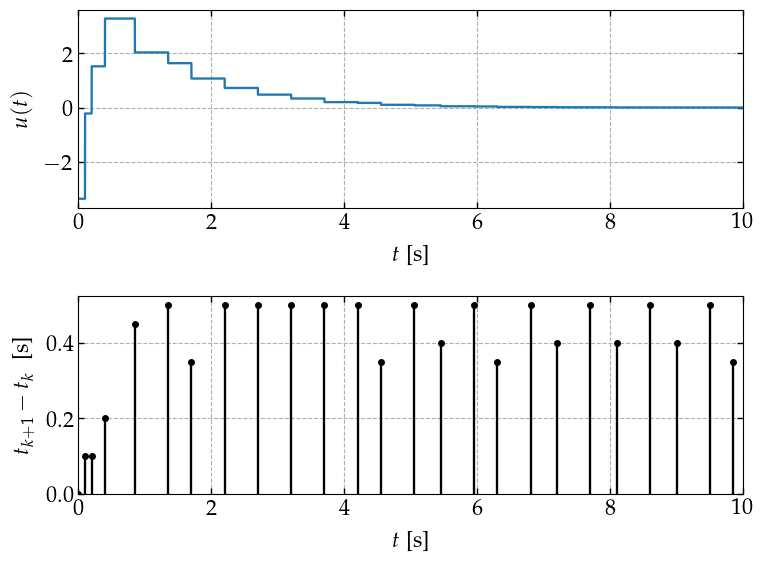

In [14]:
mosaic = [['control'], ['iet']]
fig, axs = plt.subplot_mosaic(mosaic, figsize=(8, 6))

inter_event_times = nm.compute_deltas(events)
ks_iet = np.round(
    np.array(inter_event_times) / sampling_period).astype(int).tolist()

simulation_time = exp_data["duration"]
sampling_time = exp_data["design_params"]['h']
n_samples = simulation_time / sampling_time
saving = 100.0 * (1.0 - len(events) / (n_samples))
print("Economia:", f"{saving:.2f}%")

for i in range(plant.nu):
  gph.plot(
      axs['control'], t_hist, u_hist, xlabel='$t$', x_unit='s', x_use_prefixes=True,
      ylabel=r'$u(t)$', y_pad=(0.05, 0.05),
      cfg={**cfg, 'style': {'color': colors_list[0], "linestyle": ["-"], }},)

gph.stem(
    axs['iet'], events, inter_event_times,
    reuse_previous=False, y_pad=(0.0, 0.05), x_use_prefixes=True,
    xlabel='$t$', x_unit='s', x_range=(0.0, t_hist[-1]),
    ylabel='$t_{k+1} - t_k\\;$', y_unit='s', y_use_prefixes=True,
    cfg={**cfg, 'limits': {'x_min': 0, 'x_max': t_hist[-1]}})

plt.tight_layout(pad=2.)

In [ ]:
import scipy.sparse as sp
import networkx as nx
import scipy.linalg
import numpy as np
h = sampling_period
iet_max = exp_data["design_params"]['iet_max']
K_set = [i + 1 for i in range(int(round(iet_max / h)))]

A, B, _, _ = plant.export_matrices_jit()


# 1. Obtenha as matrizes da sua planta
matrices = plant.evaluate_matrices(None, None, None)
A_cont, B_cont = matrices['A'], matrices['B']

# 2. Projete o K_ref (Âncora de Desempenho)
Q_lqr = np.eye(A_cont.shape[0])
R_lqr = np.eye(B_cont.shape[1])
P_lqr = scipy.linalg.solve_continuous_are(A_cont, B_cont, Q_lqr, R_lqr)
K_ref = -np.linalg.inv(R_lqr) @ B_cont.T @ P_lqr

print("K_ref (LQR) pronto.")


def objective_function(params):
  alpha, rho_ctrl = params

  # 1. Projeta o sistema via LMI
  res = solve_entropy_maximization(h, 0.1, alpha, rho_ctrl, K_ref)
  if res is None:
    return 0.0

  # 2. Constrói o grafo usando o SEU código original (6min36s)
  builder = tm.TrafficModelBuilder(
      A=A_cont, B=B_cont,
      K=res['controller']['K'],
      Xi=res['etm']['Ξ'],
      Psi=res['etm']['Ψ'],
      h=h, nu_bar_time=iet_max
  )

  # Retorna o objeto nx.DiGraph
  G = builder.build_exact_l_complete_graph(ell=16, K_set=K_set, verbose=True)

  # 3. Cálculo da Entropia Topológica
  if G.number_of_nodes() == 0:
    return 0.0

  # Obtemos a matriz de adjacência do grafo retornado
  adj_matrix = nx.to_scipy_sparse_array(G, weight=None)

  try:
    # Raio Espectral (rho)
    # Usamos k=1 pois só nos interessa o maior autovalor
    vals = sp.linalg.eigs(adj_matrix.astype(
        float), k=1, which='LM', return_eigenvectors=False)
    spectral_radius = np.abs(vals[0])

    # h_top = log2(rho)
    entropy = np.log2(spectral_radius) if spectral_radius > 1e-10 else 0.0
    return entropy
  except:
    return 0.0


# Teste
h_top = objective_function((0.1, 1.0))
print(f"Entropia: {h_top:.4f}")

K_ref (LQR) pronto.
=== [Init] Calculando Filtro Topológico (Main Process) ===
   Transições base mapeadas: 29
=== [Multiprocessing] Distribuindo galhos para \ell=16 ===
